# Step 1: Load Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM

# Step 2: Load and Prepare Data
#### We'll use the 20 year Stock market dataset which contains the M0M data and stick price value. Load the data using pandas and convert it to a numpy array. Normalize the data using MinMaxScaler to scale values between 0 and 1.

In [3]:
df = pd.read_csv('stock_prices_20_years_monthly.csv', header=0, parse_dates=[0], index_col=0)
data = df.values
data = data.astype('float32')


scaler = MinMaxScaler(feature_range=(0, 1))
data = scaler.fit_transform(data.reshape(-1, 1))
data.shape

(240, 1)

# Step 3: Create Sequences
#### Convert the data into input/output sequences for the RNN. Each input will be a sequence of 12 months of stock price, and each output will be the number for the next month.

In [5]:
seq_size = 12 


X = []
y = []


for i in range(seq_size, len(data)):
    X.append(data[i-seq_size:i, 0]) 
    y.append(data[i, 0])


X = np.array(X)
y = np.array(y)


X = np.reshape(X, (X.shape[0], X.shape[1], 1))
X.shape

(228, 12, 1)

# Step 4: Split Data
#### Split the data into training and testing sets. We'll use the first 100 sequences for training and the rest for testing.

In [7]:
split = 100


X_train = X[:split]
y_train = y[:split]


X_test = X[split:]
y_test = y[split:]
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((100, 12, 1), (100,), (128, 12, 1), (128,))

# Step 5: Build the RNN Model
#### Create an RNN model using the Keras Sequential API. This simple model will have a single LSTM layer followed by a Dense output layer. Compile using mean squared error loss and the Adam optimizer.

In [9]:
model = Sequential()
model.add(LSTM(50, activation='tanh', input_shape=(seq_size, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')


model.summary()

C:\Users\12146\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Step 6: Train the Model


In [11]:
model.fit(X_train, y_train, epochs=200, batch_size=16, verbose=0)
# Letting verbrose = 0, in order to suppress the output. If you would like to see it, set verbose =1.

In [13]:
y_pred = model.predict(X_test)


mse = ((y_pred - y_test)**2).mean(axis=0)
print(f'Test MSE: {mse}')

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step 
Test MSE: [0.1889529  0.15704313 0.15644003 0.15045004 0.14817654 0.15808894
 0.14324707 0.1332882  0.12353382 0.12965289 0.11477686 0.12499458
 0.11748833 0.09795859 0.1035241  0.10598763 0.10329248 0.10523877
 0.11593199 0.11325284 0.12025618 0.11397025 0.11976884 0.10476837
 0.10903458 0.10960478 0.10126814 0.10895335 0.10512099 0.09360483
 0.10356277 0.10025224 0.09650782 0.0893963  0.09618453 0.10422223
 0.09836153 0.09444458 0.09099945 0.08705293 0.08986054 0.08673327
 0.08334123 0.08622481 0.07410092 0.07053001 0.07524357 0.07069556
 0.07428086 0.06925366 0.06338457 0.06562117 0.06109338 0.05895925
 0.05605288 0.05218003 0.05217409 0.05284627 0.05390638 0.05503571
 0.05467684 0.0535501  0.05272298 0.05151404 0.05132198 0.05101451
 0.05101003 0.05439426 0.05634725 0.05495048 0.05338102 0.05476048
 0.05481277 0.05710373 0.05917305 0.05971729 0.05793787 0.0548233
 0.05441411 0.05697203 0.05825169 0.05565177 0.0566873  0.05842577
 0.0566873  0.

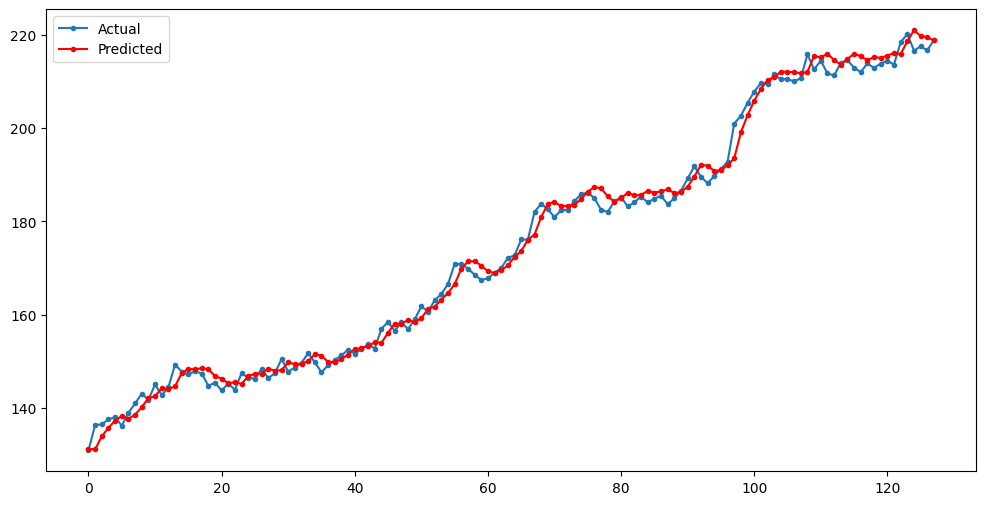

In [15]:
y_pred_inv = scaler.inverse_transform(y_pred) 
y_test_inv = scaler.inverse_transform([y_test])


plt.figure(figsize=(12,6))
plt.plot(y_test_inv.flatten(), marker='.', label="Actual")
plt.plot(y_pred_inv.flatten(), 'r', marker='.', label="Predicted")
plt.legend()
plt.show()